---

## Module 9 — Building a Chatbot with LangGraph (Part 1 of N)

This module starts a new multi-part series. Instead of isolated workflow exercises, we now build a single real-world chatbot and progressively add features to it across multiple notebooks.

---

### 🗺️ The Chatbot Roadmap

By the end of this series, the chatbot will have:

| Feature | Concept Covered |
|---|---|
| Basic chat with conversation history | State, Messages |
| Memory across turns | Memory, Persistence |
| Answer from documents | RAG |
| Take actions | Tools |
| Human approval before actions | Human-in-the-Loop (HITL) |
| Handle failures gracefully | Retry logic, Fault Tolerance |
| Observable & debuggable | LangSmith integration |
| User-facing interface | UI |

> 📌 *Each notebook in this series builds on the previous one — same chatbot, increasing complexity. By the end you'll have a production-grade agentic chatbot.*

---

### 🤖 Chatbot Design — What is it really?

A chatbot is just an LLM-based workflow with a single node, invoked repeatedly in a loop.
```
START → [chat node: LLM] → END
           ↑ (repeat for each user message)
```

One node. One LLM. That's it.

The complexity isn't in the graph structure — it's in **what we store in State** and **how we manage conversation history**.

---

### 🗂️ State Design

The most important design decision for a chatbot is its State. A chatbot needs to remember everything said so far — by both the user and the LLM.
```python
# State = the full conversation history as a list of messages
{
  "messages": [
    HumanMessage("What is the capital of India?"),
    AIMessage("New Delhi"),
    HumanMessage("What is the capital of Portugal?"),
    AIMessage("Lisbon"),
    ...
  ]
}
```

Every turn, the new message gets appended to the list and the entire history is passed to the LLM — this is how the LLM "remembers" previous turns.

> 📌 *This is called **in-context memory** — the LLM doesn't truly remember anything; it just sees the full conversation history every time. Later we'll see how LangGraph's persistence layer extends this beyond a single session.*

---



---

### 🤖 Chatbot — Part 1: Basic Chat with Conversation History

A minimal LangGraph chatbot — one node, one LLM, full conversation history preserved across turns.

---

#### Why `add_messages` instead of `operator.add`?

Both append to a list instead of replacing, but they behave differently:

| Reducer | Works with | Recommended for |
|---|---|---|
| `operator.add` | Any list | General purpose |
| `add_messages` | `BaseMessage` objects | Chatbots — LangGraph built-in, optimized for message handling |

> 📌 *`add_messages` is LangGraph's recommended reducer whenever your state holds a list of LangChain messages. It handles deduplication and edge cases that `operator.add` won't.*

---

#### Why `BaseMessage` instead of `str`?

`BaseMessage` is the parent class for all LangChain message types:
```
BaseMessage
├── HumanMessage   — typed by the user
├── AIMessage      — generated by the LLM  
├── SystemMessage  — sets the LLM's role/persona
└── ToolMessage    — result returned by a tool call
```

Using `list[BaseMessage]` means the messages list can hold any mix of these types — critical for a chatbot that will later add tools, RAG, and system prompts.

---

#### State

In [16]:
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from typing import Annotated, TypedDict
from dotenv import load_dotenv
load_dotenv(override=True)

class ChatState(TypedDict):
    # full conversation history — add_messages appends instead of replacing
    messages: Annotated[list[BaseMessage], add_messages]

---

#### Setup

In [17]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

llm = ChatOpenAI()  # gpt-3.5-turbo by default

# MemorySaver is LangGraph's in-memory checkpointer
# it persists state between invocations — this is how the chatbot "remembers"
checkpointer = MemorySaver()

> 📌 *`MemorySaver` is the simplest checkpointer — stores state in RAM. In production you'd swap this for a database-backed checkpointer (e.g. PostgreSQL). More on checkpointers in the next notebook.*

---

#### Node

In [18]:
def chat_node(state: ChatState):
    """Pass full conversation history to LLM and return its reply."""
    messages = state['messages']        # full history so far
    response = llm.invoke(messages)     # LLM sees all previous turns
    return {'messages': [response]}     # add_messages appends this to history

> 📌 *The LLM receives the full `messages` list every turn — this is how it appears to "remember" previous questions. It's not true memory; it's the entire conversation passed as context each time.*

---

#### Graph

In [29]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

# compile with checkpointer — enables state persistence across invocations
chatbot = graph.compile(checkpointer=checkpointer)

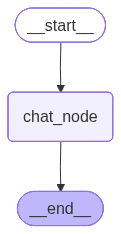

In [20]:
chatbot

---

#### Single Invocation (basic test)

In [21]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of India?')]
}

result = chatbot.invoke(initial_state)

# extract just the LLM's reply
print(result['messages'][-1].content)
# → "The capital of India is New Delhi."

The capital of India is New Delhi.


---

### 💬 The Chat Loop + The Memory Problem

---

#### The Chat Loop

In [26]:
while True:
    user_message = input("Type your message: ")
    print("USER:-> ", user_message)

    # exit keywords break the loop
    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        print("Goodbye!")
        break

    response = chatbot.invoke({"messages": [HumanMessage(content=user_message)]})
    print("AI:-> ", response['messages'][-1].content)

Type your message:  Hi I am Gourab. Nice to meet you.


USER:->  Hi I am Gourab. Nice to meet you.
AI:->  Hi Gourab, nice to meet you as well! How are you today?


Type your message:  what is my name?


USER:->  what is my name?
AI:->  I'm sorry, I am not able to access personal information about you.


Type your message:  can you add 9 and 9


USER:->  can you add 9 and 9
AI:->  Yes, 9 + 9 equals 18.


Type your message:  can you divivde the result by 2


USER:->  can you divivde the result by 2
AI:->  Yes, I can divide the result by 2. Please provide me with the number that needs to be divided by 2.


Type your message:  bye


USER:->  bye
Goodbye!


In [27]:
# ⚠️ BUG — this chatbot has no memory across turns
#
# Conversation example:
#   USER: Hi I am Gourab.         → AI remembers name ✅
#   USER: What is my name?        → AI: "I cannot access personal info" ❌
#   USER: Can you add 9 and 9?    → AI: 18 ✅
#   USER: Divide the result by 2  → AI: "Please provide the number" ❌
#
# Root cause: every invoke() starts a fresh state — previous turns are lost
# Fix: compile with checkpointer + pass config={"configurable": {"thread_id": "..."}}

---

### 🧠 Persistence — Fixing the Memory Problem

The fix is just two changes: compile with a `checkpointer` + pass `config` with a `thread_id` on every `invoke()`.

---

#### What is Persistence?

Without persistence:
```
invoke() → nodes run → state fills up → END → state erased ❌
invoke() → fresh state again → LLM has no memory of previous turns
```

With persistence:
```
invoke() → nodes run → state fills up → END → state saved to RAM ✅
invoke() → LangGraph fetches previous state from RAM → appends new message → LLM sees full history
```

> 📌 *The LLM isn't doing anything special. It just receives the full conversation history as context on every turn — because LangGraph is now restoring state between invocations instead of discarding it.*

---

#### Two Storage Options

| Storage | How | Survives program restart? | Use case |
|---|---|---|---|
| `MemorySaver` | RAM | ❌ No | Development, demos |
| Database checkpointer | PostgreSQL, SQLite etc. | ✅ Yes | Production chatbots |

> 📌 *In production (WhatsApp bots, customer support agents etc.) you always use a database-backed checkpointer — so users can close a session and pick up the same conversation days later. `MemorySaver` is for learning and prototyping only.*

---

#### What is `thread_id`?

A `thread_id` identifies one conversation session. Multiple users can talk to the same chatbot simultaneously — each gets their own thread:
```
Gourab's session  → thread_id: 1  → its own isolated state
Nitesh's session  → thread_id: 2  → its own isolated state
Rahul's session   → thread_id: 3  → its own isolated state
```

The checkpointer uses `thread_id` as the key to save and load the correct state for each user.

---

#### Fixed Chat Loop

In [30]:
thread_id = 1  # identifies this conversation session

while True:
    user_message = input("Type your message: ")
    print("USER:-> ", user_message)

    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        print("Goodbye!")
        break

    # thread_id tells the checkpointer which session's state to load/save
    config = {"configurable": {"thread_id": thread_id}}

    response = chatbot.invoke(
        {"messages": [HumanMessage(content=user_message)]},
        config=config  # ← connects this invoke() to the saved state
    )
    print("AI:-> ", response['messages'][-1].content)

Type your message:  Hi I am Gourab. Nice to meet you.


USER:->  Hi I am Gourab. Nice to meet you.
AI:->  Hello Gourab, nice to meet you as well! How can I assist you today?


Type your message:  What is my name?


USER:->  What is my name?
AI:->  Your name is Gourab.


Type your message:  Can you add 9 and 9?


USER:->  Can you add 9 and 9?
AI:->  Yes, the sum of 9 and 9 is 18.


Type your message:  Can you divide the result by 2?


USER:->  Can you divide the result by 2?
AI:->  Yes, if we divide the sum of 9 and 9, which is 18, by 2, we get 9.


Type your message:  bye


USER:->  bye
Goodbye!


Now it works correctly:
```
USER:->  Hi I am Gourab. Nice to meet you.
AI:->    Hi Gourab, nice to meet you as well!

USER:->  What is my name?
AI:->    Your name is Gourab!  ✅

USER:->  Can you add 9 and 9?
AI:->    9 + 9 = 18  ✅

USER:->  Can you divide the result by 2?
AI:->    18 / 2 = 9  ✅
```

---

#### What's happening behind the scenes
```
Turn 1: invoke("Hi I am Gourab")
        → state: [HumanMessage, AIMessage]
        → workflow ends → checkpointer saves state to RAM under thread_id=1

Turn 2: invoke("What is my name?")  
        → checkpointer fetches saved state [HumanMessage, AIMessage]
        → add_messages appends new HumanMessage → [HM, AM, HM]
        → LLM sees full history → replies correctly
        → workflow ends → checkpointer saves updated state

Turn 3: invoke("Can you add 9 and 9?")
        → checkpointer fetches [HM, AM, HM, AM]
        → appends → LLM sees everything → answers correctly
        ...and so on
```

---

#### Inspect the full state at any point

In [31]:
# pass the same config to get_state to fetch a specific session's history
state = chatbot.get_state(config)
for message in state.values['messages']:
    print(f"{message.type}: {message.content}")

human: Hi I am Gourab. Nice to meet you.
ai: Hello Gourab, nice to meet you as well! How can I assist you today?
human: What is my name?
ai: Your name is Gourab.
human: Can you add 9 and 9?
ai: Yes, the sum of 9 and 9 is 18.
human: Can you divide the result by 2?
ai: Yes, if we divide the sum of 9 and 9, which is 18, by 2, we get 9.


> 📌 *Restart the kernel → `MemorySaver` is cleared → chatbot forgets everything. This is expected behavior for RAM storage. A database checkpointer would survive restarts.*

---